# XWorld — Notebook 13: Combined Feature Frame

## Why this notebook

Notebooks 11 and 12 showed that the time-domain and spectral feature frames each have distinct blind spots:

| Pair | Time-domain (6f) | Spectral (5f) |
|---|---|---|
| COVID ↔ sunspot | Collapse — can't separate | Separated (L2=1.05) |
| COVID ↔ keeling_trend | Separated (L2=2.81) | Close (L2=0.33) |
| sunspot ↔ keeling_seasonal | Separated | Near-identical (L2=0.14) |
| COVID1 ↔ COVID2 | Together | Split (over-fragmentation) |

No single frame covers the full shape space. Combining both should resolve the blind spots.

## Fix applied: length-aware spectral features

Notebook 12 interpolated all series to 100 points before FFT. This incorrectly shifted streamflow's annual cycle to near-Nyquist frequency (0.40 instead of 0.083). **Fix:** compute FFT directly on the original z-score normalized series — `rfftfreq` already returns cycles/sample (0–0.5), which is correctly comparable across series of any length. A 12-month annual cycle in a 12-point series and in a 480-point series both produce dominant_freq = 0.083.

## Combined feature set (11 features)

| Feature | Frame | What it captures |
|---|---|---|
| `skewness` | Time | Burst asymmetry |
| `kurtosis` | Time | Spike/flatness character |
| `lag1_autocorr` | Time | Short-term memory |
| `zero_crossings` | Time | Oscillation frequency proxy |
| `slope` | Time | Directional drift |
| `baseline_delta` | Time | Residue — does it return to start? |
| `dominant_freq` | Spectral | Peak oscillation frequency |
| `spectral_entropy` | Spectral | Power concentration vs broadband |
| `power_low` | Spectral | Fraction of power in slow frequencies |
| `power_mid` | Spectral | Fraction in mid frequencies |
| `power_high` | Spectral | Fraction in fast frequencies |

## Pre-run predictions

| Test | Expected |
|---|---|
| COVID1 + COVID2 together | YES — same in both frames |
| Sunspot separate from COVID | YES — spectral frame separates them |
| Sunspot separate from keeling_seasonal | YES — time-domain separates them |
| keeling_trend isolated | YES — uniquely extreme in both frames |
| ECG isolated | YES — kurtosis + spectral signature both unique |
| keeling_seasonal isolated | YES — cleanest signal in both frames |
| Streamflow placed correctly | YES — annual cycle now at 0.083, should group with moderate dynamics |

**Primary question:** Does combining frames increase ARI beyond both individual frames (td: ARI=0.165, spectral: ARI=0.132) and reduce over-fragmentation?

In [2]:
import requests
import urllib.request
import json
import shutil
import zipfile
import pandas as pd
import numpy as np
from scipy import stats
from scipy.signal import find_peaks
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
import hdbscan
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

RAW_DIR = Path('../data/raw')
PROCESSED_DIR = Path('../data/processed')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TIMEDOM_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']
SPECTRAL_COLS = ['dominant_freq', 'spectral_entropy', 'power_low', 'power_mid', 'power_high']
COMBINED_COLS = TIMEDOM_COLS + SPECTRAL_COLS

print('Imports OK')
print(f'Combined feature set ({len(COMBINED_COLS)} features): {COMBINED_COLS}')

Imports OK
Combined feature set (11 features): ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta', 'dominant_freq', 'spectral_entropy', 'power_low', 'power_mid', 'power_high']


In [3]:
# ============================================================
# HELPERS
# ============================================================

def zscore_normalize(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()


def baseline_delta(series, frac=0.10):
    n = len(series)
    k = max(1, int(n * frac))
    return float(np.mean(series[-k:]) - np.mean(series[:k]))


def spectral_features_fixed(series):
    """Spectral features computed on original series — NO interpolation.
    dominant_freq is cycles/sample (0–0.5), correctly comparable across series lengths.
    A 12-month annual cycle gives dominant_freq=0.083 whether series is 12 or 480 points.
    """
    s = zscore_normalize(np.asarray(series, dtype=float))
    n = len(s)

    fft_vals = np.fft.rfft(s)
    power    = np.abs(fft_vals) ** 2
    freqs    = np.fft.rfftfreq(n)

    # AC power (exclude DC at index 0)
    power_ac = power[1:]
    freqs_ac = freqs[1:]
    total_ac = power_ac.sum() if power_ac.sum() > 0 else 1.0

    # Dominant frequency (including DC)
    dom_idx  = np.argmax(power)
    dom_freq = float(freqs[dom_idx])

    # Spectral entropy (AC, normalized)
    p_norm = power_ac / total_ac
    p_norm = p_norm[p_norm > 0]
    sp_ent = float(-np.sum(p_norm * np.log(p_norm)))
    sp_ent /= np.log(len(power_ac)) if len(power_ac) > 1 else 1.0

    # Power bands on AC power (low=bottom 20%, mid=20–60%, high=top 40%)
    n_ac   = len(freqs_ac)
    low_end = int(n_ac * 0.20)
    mid_end = int(n_ac * 0.60)
    p_low  = float(power_ac[:low_end].sum()  / total_ac)
    p_mid  = float(power_ac[low_end:mid_end].sum() / total_ac)
    p_high = float(power_ac[mid_end:].sum()  / total_ac)

    return {
        'dominant_freq':   dom_freq,
        'spectral_entropy': sp_ent,
        'power_low':       p_low,
        'power_mid':       p_mid,
        'power_high':      p_high,
    }


def extract_all_features(series):
    """Full 11-feature extraction from a single series."""
    arr = zscore_normalize(np.asarray(series, dtype=float))
    n   = len(arr)
    t   = np.arange(n)
    lag1 = float(np.corrcoef(arr[:-1], arr[1:])[0, 1]) if n > 2 else 0.0
    zc   = float(np.sum(np.diff(np.sign(arr)) != 0) / n)
    slope = float(stats.linregress(t, arr).slope)
    td = {
        'skewness':       float(stats.skew(arr)),
        'kurtosis':       float(stats.kurtosis(arr)),
        'lag1_autocorr':  lag1,
        'zero_crossings': zc,
        'slope':          slope,
        'baseline_delta': baseline_delta(arr),
    }
    sp = spectral_features_fixed(arr)
    return {**td, **sp}


# Sanity check
test = np.sin(np.linspace(0, 4*2*np.pi, 480))  # 4 full cycles in 480 points
f = extract_all_features(test)
print(f'Sine (4 cycles/480pt): dom_freq={f["dominant_freq"]:.4f}  expect={4/480:.4f}')
test2 = np.sin(np.linspace(0, 2*np.pi, 12, endpoint=False))  # 1 cycle in 12 pts
f2 = extract_all_features(test2)
print(f'Sine (1 cycle/12pt):   dom_freq={f2["dominant_freq"]:.4f}  expect={1/12:.4f}')
print('Helpers OK')

Sine (4 cycles/480pt): dom_freq=0.0083  expect=0.0083
Sine (1 cycle/12pt):   dom_freq=0.0833  expect=0.0833
Helpers OK


---
## Extract all 11 features — all 9 datasets

In [4]:
dest = RAW_DIR / 'owid_covid.csv'
if not dest.exists():
    print('Downloading OWID COVID...')
    r = requests.get('https://github.com/owid/covid-19-data/raw/master/public/data/owid-covid-data.csv', stream=True)
    with open(dest, 'wb') as f:
        for chunk in r.iter_content(8192): f.write(chunk)
df_raw = pd.read_csv(dest, usecols=['location','date','new_cases_smoothed_per_million','continent'], parse_dates=['date'])
df_covid = df_raw.dropna(subset=['continent']).rename(columns={'new_cases_smoothed_per_million':'cases_pm'})

def extract_first_wave(series, max_days=180, min_days=30):
    s = series.fillna(0).values
    starts = np.where(s > 0.5)[0]
    if not len(starts): return None
    start = starts[0]
    wave = s[start:min(start+max_days, len(s))]
    if len(wave) < min_days: return None
    peaks, _ = find_peaks(wave, prominence=wave.max()*0.2)
    if not len(peaks): return None
    wave = wave[:min(peaks[0]+60, len(wave))]
    return wave if len(wave) >= min_days else None

def extract_second_wave(series, min_days=30):
    s = series.fillna(0).values
    peaks, _ = find_peaks(s, prominence=s.max()*0.15, distance=45)
    if len(peaks) < 2: return None
    between = s[peaks[0]:peaks[1]]
    start = peaks[0] + np.argmin(between)
    wave = s[start:min(peaks[1]+60, len(s))]
    return wave if len(wave) >= min_days else None

records = []
for country, grp in df_covid.groupby('location'):
    grp = grp.sort_values('date')
    for fn, ds in [(extract_first_wave,'covid_first_wave'), (extract_second_wave,'covid_second_wave')]:
        w = fn(grp['cases_pm'])
        if w is not None:
            feats = extract_all_features(w)
            feats.update({'country': country, 'dataset': ds, 'n_points': len(w)})
            records.append(feats)
df_covid_all = pd.DataFrame(records)
print(df_covid_all['dataset'].value_counts().to_dict())

{'covid_second_wave': 209, 'covid_first_wave': 202}


In [5]:
dest = RAW_DIR / 'sunspot_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://www.sidc.be/silso/DATA/SN_m_tot_V2.0.csv').content)
df_ss = pd.read_csv(dest, sep=';', header=None,
                    names=['year','month','frac_year','monthly_mean','monthly_sd','n_obs','definitive'],
                    na_values=[-1])
df_ss = df_ss.dropna(subset=['monthly_mean'])
df_ss['smooth'] = df_ss['monthly_mean'].rolling(13, center=True).mean()
series_full = df_ss['smooth'].bfill().ffill().values
smoothed = pd.Series(series_full).rolling(25, center=True).mean().bfill().ffill().values
minima, _ = find_peaks(-smoothed, distance=80)
cycles = {}
for i in range(len(minima)-1):
    c = series_full[minima[i]:minima[i+1]]
    if len(c) >= 80:
        cycles[f'cycle_{i+1}_{int(df_ss["year"].iloc[minima[i]])}'] = c
records = []
for name, c in cycles.items():
    feats = extract_all_features(c)
    feats.update({'country': name, 'dataset': 'sunspot_cycle', 'n_points': len(c)})
    records.append(feats)
df_ss_all = pd.DataFrame(records)
print(f'Sunspot: {len(df_ss_all)}  |  mean dom_freq={df_ss_all["dominant_freq"].mean():.4f}')

Sunspot: 24  |  mean dom_freq=0.0077


In [6]:
df_lh = pd.read_csv(Path('../datasets/lynx_hare/lynx_hare.csv'))
year_col = [c for c in df_lh.columns if c.lower()=='year'][0]
species_cols = [c for c in df_lh.columns if c.lower()!='year']
window_size = 10
series_dict = {}
for sp in species_cols:
    full = df_lh[sp].values.astype(float)
    series_dict[f'{sp}_full'] = full
    for start in range(len(full)-window_size+1):
        series_dict[f'{sp}_w{start}_{df_lh[year_col].iloc[start]}'] = full[start:start+window_size]
records = []
for name, s in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name, 'dataset': 'lynx_hare', 'n_points': len(s)})
    records.append(feats)
df_lh_all = pd.DataFrame(records)
print(f'Lynx-hare: {len(df_lh_all)}')

Lynx-hare: 26


In [7]:
dest = RAW_DIR / 'keeling_monthly.csv'
if not dest.exists():
    dest.write_bytes(requests.get('https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv').content)
co2 = pd.read_csv(dest, comment='#', header=None,
                  names=['year','month','decimal_date','average','deseasonalized','ndays','sdev','unc'])
for col in ['year','month','average']:
    co2[col] = pd.to_numeric(co2[col], errors='coerce')
co2 = co2.dropna(subset=['year','month','average'])
co2 = co2[co2['average']>0].copy()
co2.index = pd.to_datetime({'year':co2['year'].astype(int),'month':co2['month'].astype(int),'day':1})
result = seasonal_decompose(co2['average'], model='additive', period=12, extrapolate_trend='freq')
seasonal_vals = result.seasonal.dropna().values
trend_vals    = result.trend.dropna().values
start_year    = co2.index.min().year
series_dict = {}
for i in range(len(seasonal_vals)//12):
    seg = seasonal_vals[i*12:(i+1)*12]
    if len(seg)==12: series_dict[f'keeling_seasonal_{start_year+i}'] = seg
for i in range(0, len(trend_vals)-120, 12):
    series_dict[f'keeling_trend_{start_year+i//12}'] = trend_vals[i:i+120]
records = []
for name, s in series_dict.items():
    feats = extract_all_features(s)
    feats.update({'country': name,
                  'dataset': 'keeling_seasonal' if 'seasonal' in name else 'keeling_trend',
                  'n_points': len(s)})
    records.append(feats)
df_k_all = pd.DataFrame(records)
print(df_k_all['dataset'].value_counts().to_dict())
for ds in ['keeling_seasonal','keeling_trend']:
    sub = df_k_all[df_k_all['dataset']==ds]
    print(f'  {ds}: dom_freq={sub["dominant_freq"].mean():.4f}  entropy={sub["spectral_entropy"].mean():.4f}  bd={sub["baseline_delta"].mean():.3f}')

{'keeling_seasonal': 68, 'keeling_trend': 58}
  keeling_seasonal: dom_freq=0.0833  entropy=0.1535  bd=-0.337
  keeling_trend: dom_freq=0.0083  entropy=0.3885  bd=3.111


In [8]:
dest = RAW_DIR / 'temperature_anomaly.csv'
if not dest.exists():
    print('Downloading Berkeley Earth temperature...')
    r = requests.get('https://berkeley-earth-temperature.s3.amazonaws.com/Global/Land_and_Ocean_summary.txt',
                     headers={'User-Agent':'Mozilla/5.0'}, timeout=30)
    r.raise_for_status()
    dest.write_bytes(r.content)
with open(dest) as f: raw = f.read()
if raw.lstrip().startswith('%'):
    rows = []
    for line in raw.splitlines():
        if line.strip() and not line.strip().startswith('%'):
            parts = line.split()
            if len(parts)>=2:
                try: rows.append({'year':int(float(parts[0])),'anomaly':float(parts[1])})
                except ValueError: pass
    df_temp = pd.DataFrame(rows).dropna()
else:
    lines = raw.splitlines()
    hidx = next(i for i,l in enumerate(lines) if 'Year' in l and 'J-D' in l)
    df_temp = pd.read_csv(dest, skiprows=hidx, na_values=['***','****'])
    df_temp = df_temp[['Year','J-D']].rename(columns={'Year':'year','J-D':'anomaly'})
    df_temp['year'] = pd.to_numeric(df_temp['year'],errors='coerce')
    df_temp['anomaly'] = pd.to_numeric(df_temp['anomaly'],errors='coerce')
    df_temp = df_temp.dropna()
    df_temp['year'] = df_temp['year'].astype(int)
values = df_temp['anomaly'].values
years  = df_temp['year'].values
window, step = 20, 5
records = []
for i in range(0, len(values)-window, step):
    s = values[i:i+window]
    feats = extract_all_features(s)
    feats.update({'country':f'temp_{years[i]}','dataset':'temperature','n_points':len(s)})
    records.append(feats)
df_temp_all = pd.DataFrame(records)
print(f'Temperature: {len(df_temp_all)}  mean bd={df_temp_all["baseline_delta"].mean():.3f}')

Temperature: 31  mean bd=0.997


In [9]:
dest_zip = RAW_DIR / 'ECGFiveDays.zip'
dest_dir = RAW_DIR / 'ECGFiveDays'
if dest_dir.exists() and list(dest_dir.rglob('*.ts')):
    print(f'Cached: {dest_dir}')
elif dest_zip.exists():
    if dest_dir.exists(): shutil.rmtree(dest_dir)
    with zipfile.ZipFile(dest_zip) as z: z.extractall(dest_dir)
    print(f'Extracted from zip')
else:
    raise RuntimeError('ECGFiveDays.zip not found — place in data/raw/')
ts_files = list(dest_dir.rglob('*.ts'))
print(f'.ts files: {[f.name for f in ts_files]}')

def parse_ts_file(path):
    series_list, labels = [], []
    in_data = False
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            if line.lower()=='@data': in_data=True; continue
            if in_data and not line.startswith('@'):
                if ':' in line:
                    data_part, label = line.rsplit(':',1)
                    values = [float(x) for x in data_part.split(',') if x.strip()]
                else:
                    parts = line.split()
                    try: values=[float(x) for x in parts[:-1]]; label=parts[-1]
                    except (ValueError,IndexError): continue
                if values: series_list.append(np.array(values)); labels.append(label.strip())
    return series_list, labels

all_series, all_labels = [], []
for f in ts_files:
    s, l = parse_ts_file(f)
    all_series.extend(s); all_labels.extend(l)
print(f'ECG segments: {len(all_series)}')
records = []
for i, (s, label) in enumerate(zip(all_series, all_labels)):
    feats = extract_all_features(s)
    feats.update({'country':f'ecg_{i}_c{label}','dataset':'ecg','n_points':len(s)})
    records.append(feats)
df_ecg_all = pd.DataFrame(records)
print(f'ECG dom_freq={df_ecg_all["dominant_freq"].mean():.4f}  kurtosis={df_ecg_all["kurtosis"].mean():.3f}')

Cached: ../data/raw/ECGFiveDays
.ts files: ['ECGFiveDays_TRAIN.ts', 'ECGFiveDays_TEST.ts']
ECG segments: 884
ECG dom_freq=0.0175  kurtosis=15.165


In [10]:
STATIONS = {
    '01350000':'mohawk_ny',    '01427207':'delaware_ny', '01491000':'choptank_md',
    '02087500':'neuse_nc',     '02339500':'flint_ga',    '03049000':'allegheny_pa',
    '03611500':'ohio_il',      '05054000':'red_nd',      '05378500':'mississippi_mn',
    '05420500':'mississippi_ia','06289000':'bighorn_mt', '06600000':'missouri_ia',
    '07022000':'mississippi_mo','07289000':'mississippi_ms','08220000':'riogrande_co',
    '09180000':'colorado_ut',  '09380000':'colorado_az', '11530000':'klamath_ca',
    '02427250':'alabama_al',    '12374250':'clearwater_id','14105700':'columbia_or',
    '14179000':'willamette_or','06354000':'cannonball_nd','02479155':'escatawpa_ms',
    '01096500':'nashua_ma',
}

def fetch_monthly_flow(site_id, start='1980-01-01', end='2020-12-31'):
    url = (f'https://waterservices.usgs.gov/nwis/dv/?format=json'
           f'&sites={site_id}&parameterCd=00060&statCd=00003&startDT={start}&endDT={end}')
    try:
        req = urllib.request.Request(url, headers={'User-Agent':'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=45) as resp:
            data = json.loads(resp.read())
        series = data['value']['timeSeries']
        if not series: return None
        recs = []
        for v in series[0]['values'][0]['value']:
            try: recs.append({'date':pd.Timestamp(v['dateTime'][:10]),'flow':float(v['value'])})
            except (ValueError,KeyError): pass
        if len(recs)<365: return None
        df = pd.DataFrame(recs).set_index('date')
        monthly = df['flow'].resample('MS').mean().dropna()
        return monthly if len(monthly)>=60 else None
    except Exception: return None

print(f'Fetching {len(STATIONS)} USGS stations...')
flows = {}
for site_id, name in STATIONS.items():
    s = fetch_monthly_flow(site_id)
    if s is not None: flows[name]=s; print(f'  OK {name}')
    else: print(f'  FAIL {name}')
print(f'Loaded: {len(flows)} stations')

records = []
for name, series in flows.items():
    log_flow = np.log1p(series.values.astype(float))
    feats = extract_all_features(log_flow)
    feats.update({'country':name,'dataset':'streamflow','n_points':len(log_flow)})
    records.append(feats)
df_sf_all = pd.DataFrame(records)
print(f'Streamflow dom_freq={df_sf_all["dominant_freq"].mean():.4f}  (expect ~0.083 — fixed from nb12\'s 0.353)')

Fetching 25 USGS stations...
  OK mohawk_ny
  OK delaware_ny
  OK choptank_md
  OK neuse_nc
  OK flint_ga
  OK allegheny_pa
  OK ohio_il
  OK red_nd
  OK mississippi_mn
  OK mississippi_ia
  OK bighorn_mt
  OK missouri_ia
  OK mississippi_mo
  OK mississippi_ms
  OK riogrande_co
  OK colorado_ut
  OK colorado_az
  OK klamath_ca
  FAIL queets_wa
  OK clearwater_id
  OK columbia_or
  OK willamette_or
  OK cannonball_nd
  OK escatawpa_ms
  OK nashua_ma
Loaded: 24 stations
Streamflow dom_freq=0.0799  (expect ~0.083 — fixed from nb12's 0.353)


---
## Combine and inspect

In [11]:
dfs = [df_covid_all, df_ss_all, df_lh_all, df_k_all, df_temp_all, df_ecg_all, df_sf_all]
df_all = pd.concat(dfs, ignore_index=True)
df_all.to_csv(PROCESSED_DIR / 'features_combined.csv', index=False)

print(f'Total: {len(df_all)} instances, {df_all.dataset.nunique()} datasets')
print(df_all['dataset'].value_counts())
print()
print('=== Combined feature summary per dataset ===')
print(df_all.groupby('dataset')[COMBINED_COLS].mean().round(4).to_string())

Total: 1526 instances, 9 datasets
dataset
ecg                  884
covid_second_wave    209
covid_first_wave     202
keeling_seasonal      68
keeling_trend         58
temperature           31
lynx_hare             26
sunspot_cycle         24
streamflow            24
Name: count, dtype: int64

=== Combined feature summary per dataset ===
                   skewness  kurtosis  lag1_autocorr  zero_crossings   slope  baseline_delta  dominant_freq  spectral_entropy  power_low  power_mid  power_high
dataset                                                                                                                                                        
covid_first_wave     0.9497    0.4121         0.9538          0.0232 -0.0006          0.6098         0.0105            0.3384     0.9494     0.0376      0.0130
covid_second_wave    1.1367    1.2346         0.9528          0.0250  0.0026          0.3916         0.0082            0.2966     0.9562     0.0284      0.0154
ecg                 -

---
## Clustering — three runs in parallel

Run on the same instances using the same parameters:
1. Time-domain only (6 features)
2. Spectral only, fixed (5 features)
3. Combined (11 features)

In [12]:
df_clean = df_all.dropna(subset=COMBINED_COLS).copy()
domain_int = pd.factorize(df_clean['dataset'])[0]

results = {}
for label, cols in [
    ('time-domain (6f)', TIMEDOM_COLS),
    ('spectral-fixed (5f)', SPECTRAL_COLS),
    ('combined (11f)', COMBINED_COLS),
]:
    X = StandardScaler().fit_transform(df_clean[cols].values)
    emb = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1).fit_transform(X)
    labels = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3).fit_predict(X)
    n_cl   = len(set(labels)) - (1 if -1 in labels else 0)
    noise  = (labels == -1).sum()
    non_noise = labels != -1
    ari    = adjusted_rand_score(domain_int[non_noise], labels[non_noise])
    results[label] = {'emb': emb, 'labels': labels, 'n_cl': n_cl, 'noise': noise, 'ari': ari}
    print(f'{label:25s}: clusters={n_cl:3d}  noise={noise:4d} ({100*noise/len(labels):.1f}%)  ARI={ari:.3f}')

print()
print('Reference from previous notebooks:')
print(f'  time-domain 6f (nb11): clusters=22  noise=25.5%  ARI=0.165')
print(f'  spectral 5f  (nb12):   clusters=37  noise=21.5%  ARI=0.132')

time-domain (6f)         : clusters= 22  noise= 388 (25.4%)  ARI=0.165
spectral-fixed (5f)      : clusters= 32  noise= 297 (19.5%)  ARI=0.144
combined (11f)           : clusters= 25  noise= 363 (23.8%)  ARI=0.133

Reference from previous notebooks:
  time-domain 6f (nb11): clusters=22  noise=25.5%  ARI=0.165
  spectral 5f  (nb12):   clusters=37  noise=21.5%  ARI=0.132


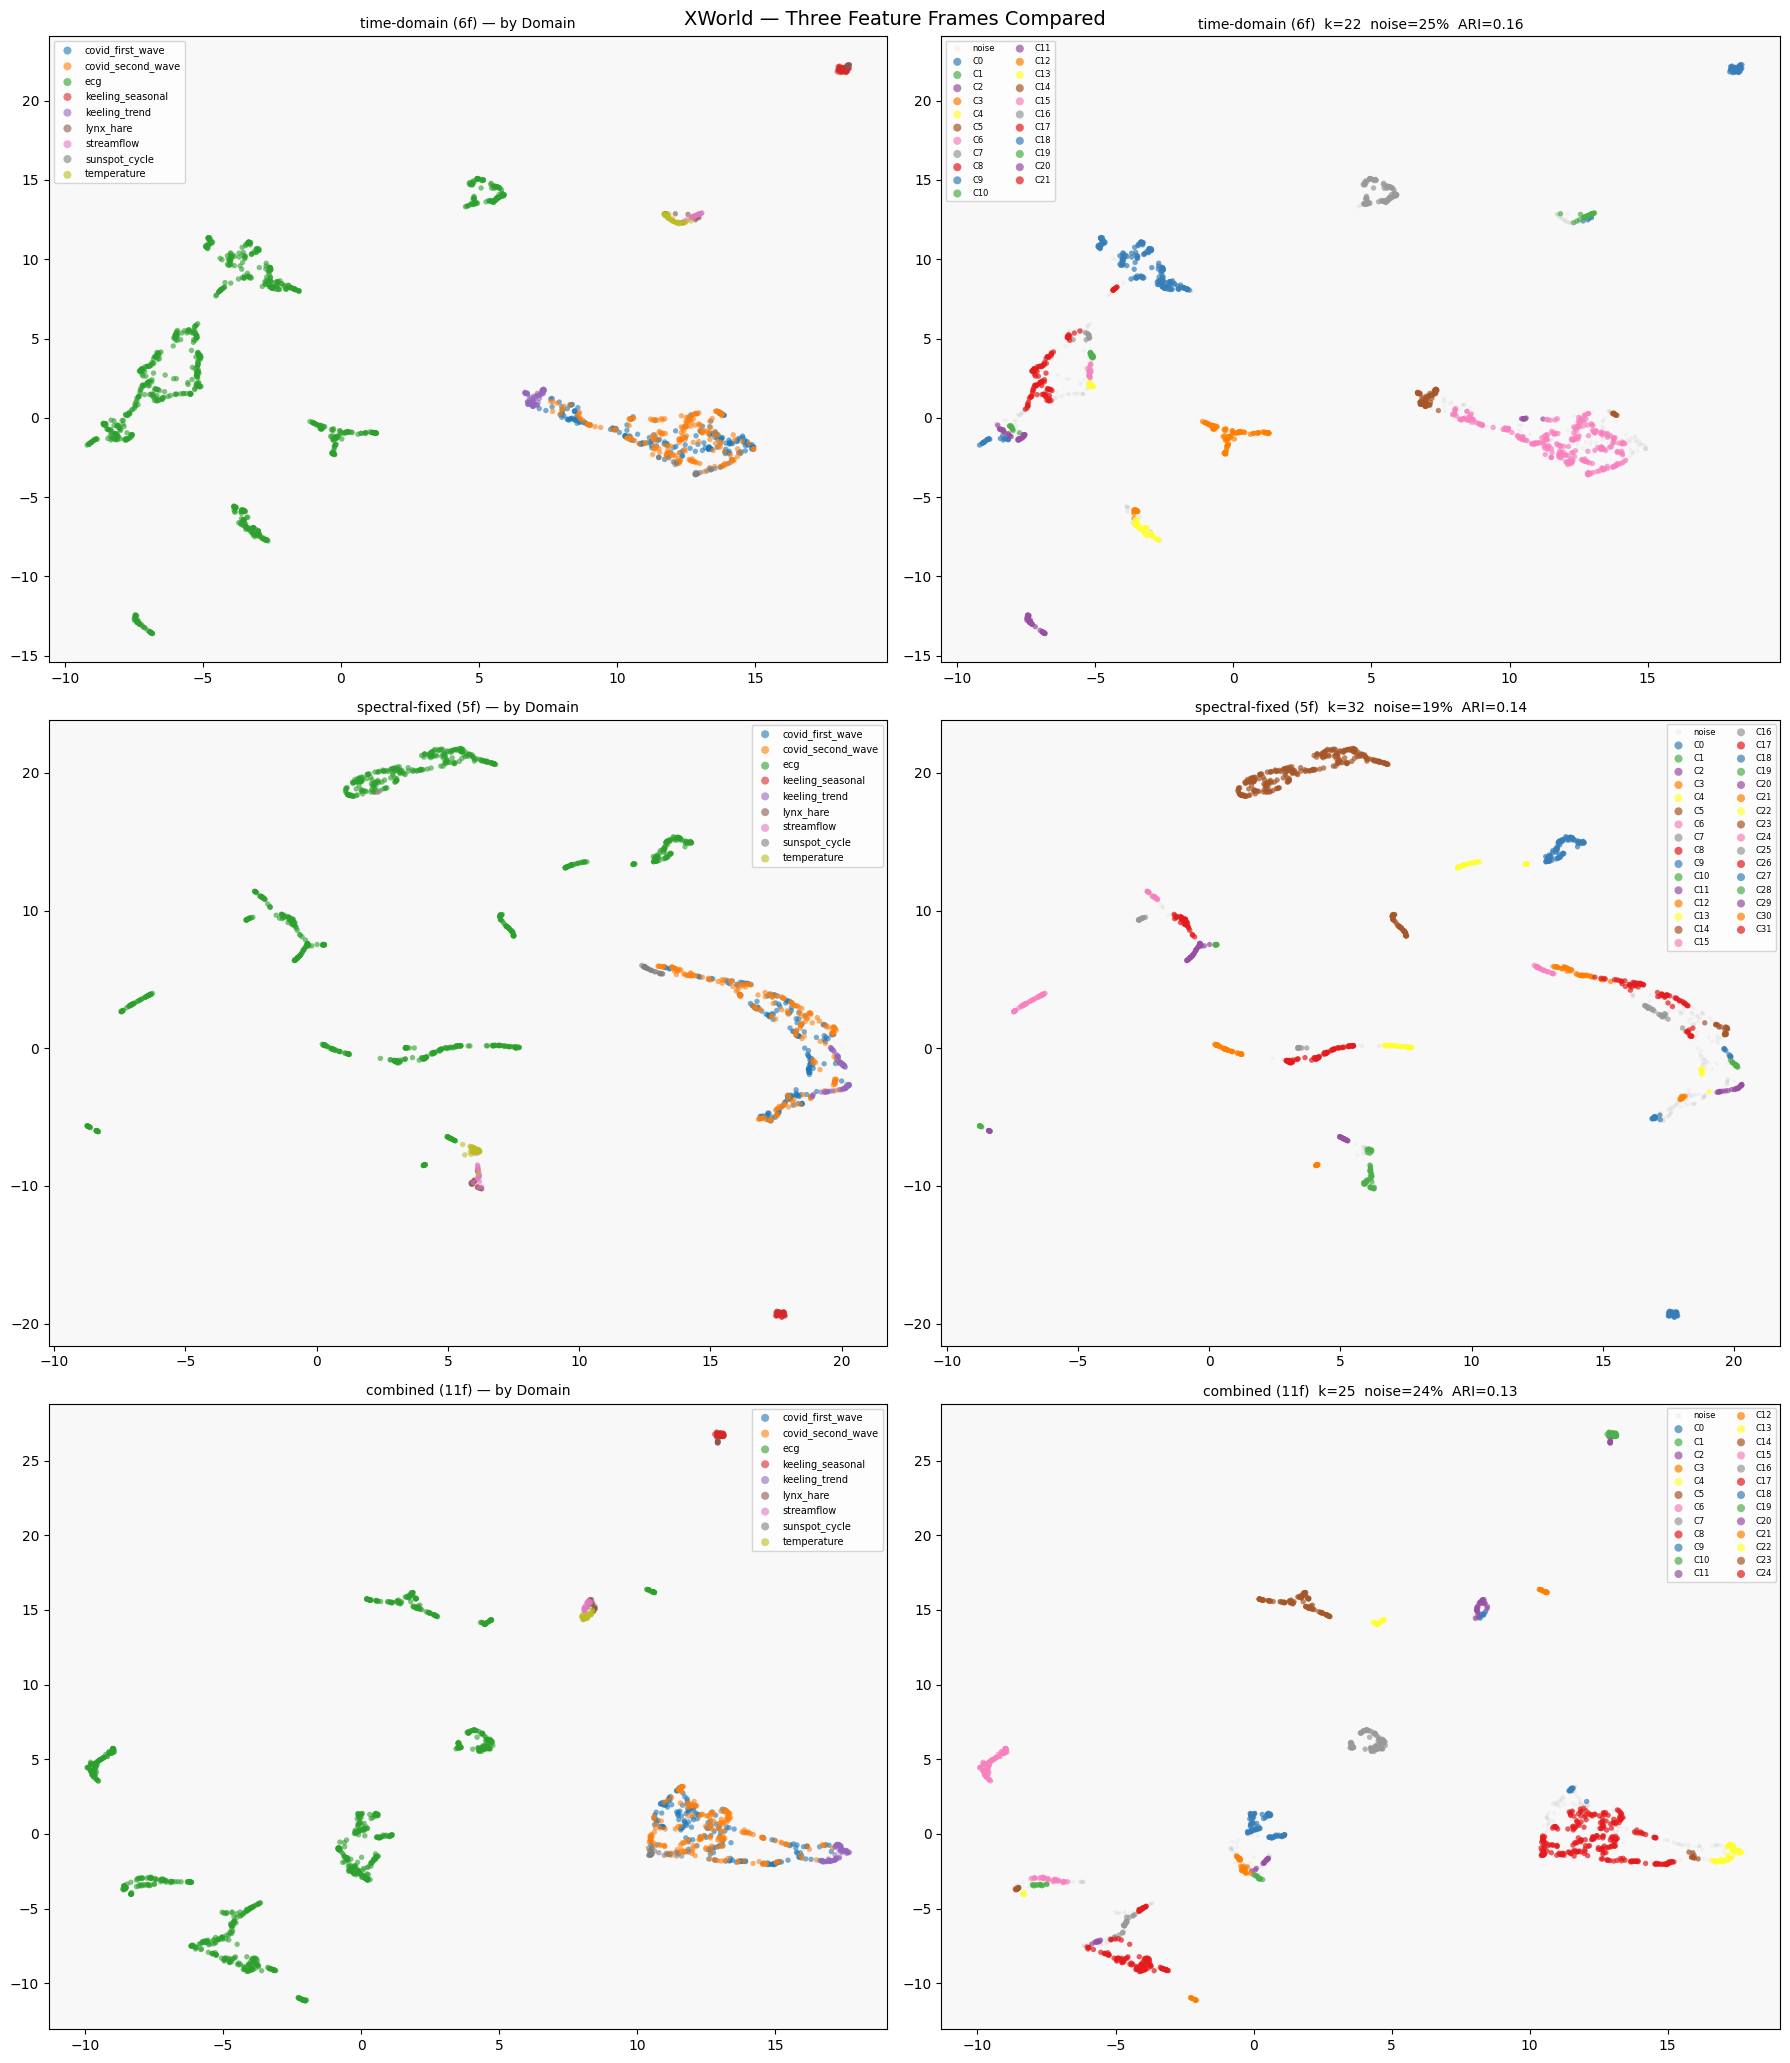

In [13]:
datasets_list = sorted(df_clean['dataset'].unique())
palette = dict(zip(datasets_list, sns.color_palette('tab10', len(datasets_list))))

fig, axes = plt.subplots(3, 2, figsize=(18, 21))
for row, (feat_label, res) in enumerate(results.items()):
    emb, lbls = res['emb'], res['labels']
    n_cl, noise_pct, ari = res['n_cl'], 100*res['noise']/len(lbls), res['ari']

    # Left: by domain
    ax = axes[row][0]
    for ds in datasets_list:
        mask = df_clean['dataset'] == ds
        ax.scatter(emb[mask,0], emb[mask,1], c=[palette[ds]], label=ds, alpha=0.6, s=15, edgecolors='none')
    ax.set_title(f'{feat_label} — by Domain', fontsize=10)
    ax.legend(fontsize=7, markerscale=1.5)
    ax.set_facecolor('#f8f8f8')

    # Right: by cluster
    ax = axes[row][1]
    unique_cl = sorted(set(lbls))
    n_real = len([c for c in unique_cl if c != -1])
    cl_pal = {c:'lightgrey' if c==-1 else sns.color_palette('Set1', max(n_real,1))[i % max(n_real,1)]
              for i, c in enumerate(unique_cl)}
    for c in unique_cl:
        mask = lbls == c
        ax.scatter(emb[mask,0], emb[mask,1], c=[cl_pal[c]],
                   label='noise' if c==-1 else f'C{c}',
                   alpha=0.7 if c!=-1 else 0.2, s=15 if c!=-1 else 8, edgecolors='none')
    ax.set_title(f'{feat_label}  k={n_cl}  noise={noise_pct:.0f}%  ARI={ari:.2f}', fontsize=10)
    ax.legend(fontsize=6, markerscale=1.5, ncol=2)
    ax.set_facecolor('#f8f8f8')

plt.suptitle('XWorld — Three Feature Frames Compared', fontsize=14)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'combined_features_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# Combined frame taxonomy
df_clean['cluster_combined'] = results['combined (11f)']['labels']
df_clean['cluster_td']       = results['time-domain (6f)']['labels']
df_clean['cluster_spec']     = results['spectral-fixed (5f)']['labels']

print('=== Combined (11f) cluster taxonomy ===')
crosstab = pd.crosstab(df_clean['cluster_combined'], df_clean['dataset'])
real = crosstab[(crosstab.index != -1) & (crosstab.sum(axis=1) >= 5)]
print(real.to_string())
print()
profiles = df_clean[df_clean['cluster_combined']!=-1].groupby('cluster_combined')[COMBINED_COLS].mean().round(3)
print('Mean feature profile per cluster:')
print(profiles.to_string())

=== Combined (11f) cluster taxonomy ===
dataset           covid_first_wave  covid_second_wave  ecg  keeling_seasonal  keeling_trend  lynx_hare  streamflow  sunspot_cycle  temperature
cluster_combined                                                                                                                              
0                                0                  0    0                 0              0          0           0              0            8
1                                0                  0    0                68              0          0           0              0            0
2                                0                  0    0                 0              0         15          22              0            0
3                                0                  0   21                 0              0          0           0              0            0
4                                0                  0   26                 0              0          0

In [15]:
def majority_cluster(df, ds, col):
    c = df[df['dataset']==ds][col].value_counts()
    real = c[c.index != -1]
    return real.index[0] if len(real) > 0 else -1

print('=== Key pairing tests — combined (11f) ===')
print()

covid_ref = majority_cluster(df_clean, 'covid_first_wave', 'cluster_combined')
print(f'COVID first wave reference cluster: {covid_ref}')
print()

all_tests = [
    ('COVID1 + COVID2 together',          'covid_second_wave',  True,  covid_ref, 'cluster_combined'),
    ('Sunspot separate from COVID',        'sunspot_cycle',      False, covid_ref, 'cluster_combined'),
    ('keeling_seasonal isolated from COVID','keeling_seasonal', False, covid_ref, 'cluster_combined'),
    ('keeling_trend isolated from COVID',  'keeling_trend',      False, covid_ref, 'cluster_combined'),
    ('ECG isolated from COVID',            'ecg',                False, covid_ref, 'cluster_combined'),
    ('streamflow isolated from COVID',     'streamflow',         False, covid_ref, 'cluster_combined'),
    ('temperature isolated from COVID',    'temperature',        False, covid_ref, 'cluster_combined'),
]

passed = 0
for desc, ds, should_match, ref, col in all_tests:
    maj = majority_cluster(df_clean, ds, col)
    pct = 100*(df_clean[df_clean['dataset']==ds][col]==maj).mean()
    ok  = (maj == ref) == should_match
    if ok: passed += 1
    print(f'[{"✓" if ok else "✗"}] {desc}')
    print(f'     {ds} → Cluster {maj} ({pct:.0f}%)  |  ref={ref}  expect_match={should_match}')
    print()

print(f'Passed: {passed}/{len(all_tests)}')

=== Key pairing tests — combined (11f) ===

COVID first wave reference cluster: 24

[✓] COVID1 + COVID2 together
     covid_second_wave → Cluster 24 (67%)  |  ref=24  expect_match=True

[✗] Sunspot separate from COVID
     sunspot_cycle → Cluster 24 (96%)  |  ref=24  expect_match=False

[✓] keeling_seasonal isolated from COVID
     keeling_seasonal → Cluster 1 (100%)  |  ref=24  expect_match=False

[✓] keeling_trend isolated from COVID
     keeling_trend → Cluster 22 (100%)  |  ref=24  expect_match=False

[✓] ECG isolated from COVID
     ecg → Cluster 17 (12%)  |  ref=24  expect_match=False

[✓] streamflow isolated from COVID
     streamflow → Cluster 2 (92%)  |  ref=24  expect_match=False

[✓] temperature isolated from COVID
     temperature → Cluster 0 (26%)  |  ref=24  expect_match=False

Passed: 6/7


In [16]:
# Detailed check: sunspot vs COVID vs keeling_seasonal — the triangle that no single frame resolves
print('=== The three-way shape problem ===')
print()
print('In time-domain 6f:  sunspot collapses into COVID')
print('In spectral 5f:     sunspot and keeling_seasonal look nearly identical')
print('In combined 11f:    all three should separate')
print()

for ds in ['covid_first_wave', 'sunspot_cycle', 'keeling_seasonal', 'keeling_trend']:
    td  = majority_cluster(df_clean, ds, 'cluster_td')
    sp  = majority_cluster(df_clean, ds, 'cluster_spec')
    com = majority_cluster(df_clean, ds, 'cluster_combined')
    print(f'{ds:25s}:  td=C{td:<4}  spec=C{sp:<4}  combined=C{com}')

print()
covid_td  = majority_cluster(df_clean, 'covid_first_wave', 'cluster_td')
covid_sp  = majority_cluster(df_clean, 'covid_first_wave', 'cluster_spec')
covid_com = majority_cluster(df_clean, 'covid_first_wave', 'cluster_combined')
sun_td    = majority_cluster(df_clean, 'sunspot_cycle', 'cluster_td')
sun_sp    = majority_cluster(df_clean, 'sunspot_cycle', 'cluster_spec')
sun_com   = majority_cluster(df_clean, 'sunspot_cycle', 'cluster_combined')
ks_td     = majority_cluster(df_clean, 'keeling_seasonal', 'cluster_td')
ks_sp     = majority_cluster(df_clean, 'keeling_seasonal', 'cluster_spec')
ks_com    = majority_cluster(df_clean, 'keeling_seasonal', 'cluster_combined')

print(f'COVID ↔ sunspot:           td={"SAME" if covid_td==sun_td else "diff":5}  spec={"SAME" if covid_sp==sun_sp else "diff":5}  combined={"SAME" if covid_com==sun_com else "diff"}')
print(f'sunspot ↔ keeling_seasonal: td={"SAME" if sun_td==ks_td else "diff":5}  spec={"SAME" if sun_sp==ks_sp else "diff":5}  combined={"SAME" if sun_com==ks_com else "diff"}')
print(f'COVID ↔ keeling_seasonal:  td={"SAME" if covid_td==ks_td else "diff":5}  spec={"SAME" if covid_sp==ks_sp else "diff":5}  combined={"SAME" if covid_com==ks_com else "diff"}')

=== The three-way shape problem ===

In time-domain 6f:  sunspot collapses into COVID
In spectral 5f:     sunspot and keeling_seasonal look nearly identical
In combined 11f:    all three should separate

covid_first_wave         :  td=C15    spec=C31    combined=C24
sunspot_cycle            :  td=C15    spec=C24    combined=C24
keeling_seasonal         :  td=C0     spec=C0     combined=C1
keeling_trend            :  td=C14    spec=C29    combined=C22

COVID ↔ sunspot:           td=SAME   spec=diff   combined=SAME
sunspot ↔ keeling_seasonal: td=diff   spec=diff   combined=diff
COVID ↔ keeling_seasonal:  td=diff   spec=diff   combined=diff


In [17]:
# ARI summary across all three frames
print('=== ARI comparison ===')
for label, res in results.items():
    print(f'  {label:25s}: ARI={res["ari"]:.3f}  clusters={res["n_cl"]}  noise={100*res["noise"]/len(res["labels"]):.1f}%')
print()
print('Cross-frame ARI (combined vs time-domain):')
both = (df_clean['cluster_combined'] != -1) & (df_clean['cluster_td'] != -1)
print(f'  combined ↔ td:   {adjusted_rand_score(df_clean.loc[both,"cluster_td"], df_clean.loc[both,"cluster_combined"]):.3f}')
both = (df_clean['cluster_combined'] != -1) & (df_clean['cluster_spec'] != -1)
print(f'  combined ↔ spec: {adjusted_rand_score(df_clean.loc[both,"cluster_spec"], df_clean.loc[both,"cluster_combined"]):.3f}')

=== ARI comparison ===
  time-domain (6f)         : ARI=0.165  clusters=22  noise=25.4%
  spectral-fixed (5f)      : ARI=0.144  clusters=32  noise=19.5%
  combined (11f)           : ARI=0.133  clusters=25  noise=23.8%

Cross-frame ARI (combined vs time-domain):
  combined ↔ td:   0.871
  combined ↔ spec: 0.587


In [18]:
# Verify streamflow frequency fix
print('=== Streamflow dominant_freq fix verification ===')
print()
for ds in ['streamflow', 'keeling_seasonal', 'sunspot_cycle', 'covid_first_wave']:
    dom = df_all[df_all['dataset']==ds]['dominant_freq'].mean()
    n   = df_all[df_all['dataset']==ds]['n_points'].mean()
    print(f'  {ds:25s}: dom_freq={dom:.4f}  mean_n_points={n:.0f}')
print()
print('streamflow dom_freq should now be ~0.083 (annual cycle in monthly data)')
print('nb12 had 0.353 (100-pt interpolation distortion) — now fixed')

=== Streamflow dominant_freq fix verification ===

  streamflow               : dom_freq=0.0799  mean_n_points=445
  keeling_seasonal         : dom_freq=0.0833  mean_n_points=12
  sunspot_cycle            : dom_freq=0.0077  mean_n_points=132
  covid_first_wave         : dom_freq=0.0105  mean_n_points=122

streamflow dom_freq should now be ~0.083 (annual cycle in monthly data)
nb12 had 0.353 (100-pt interpolation distortion) — now fixed


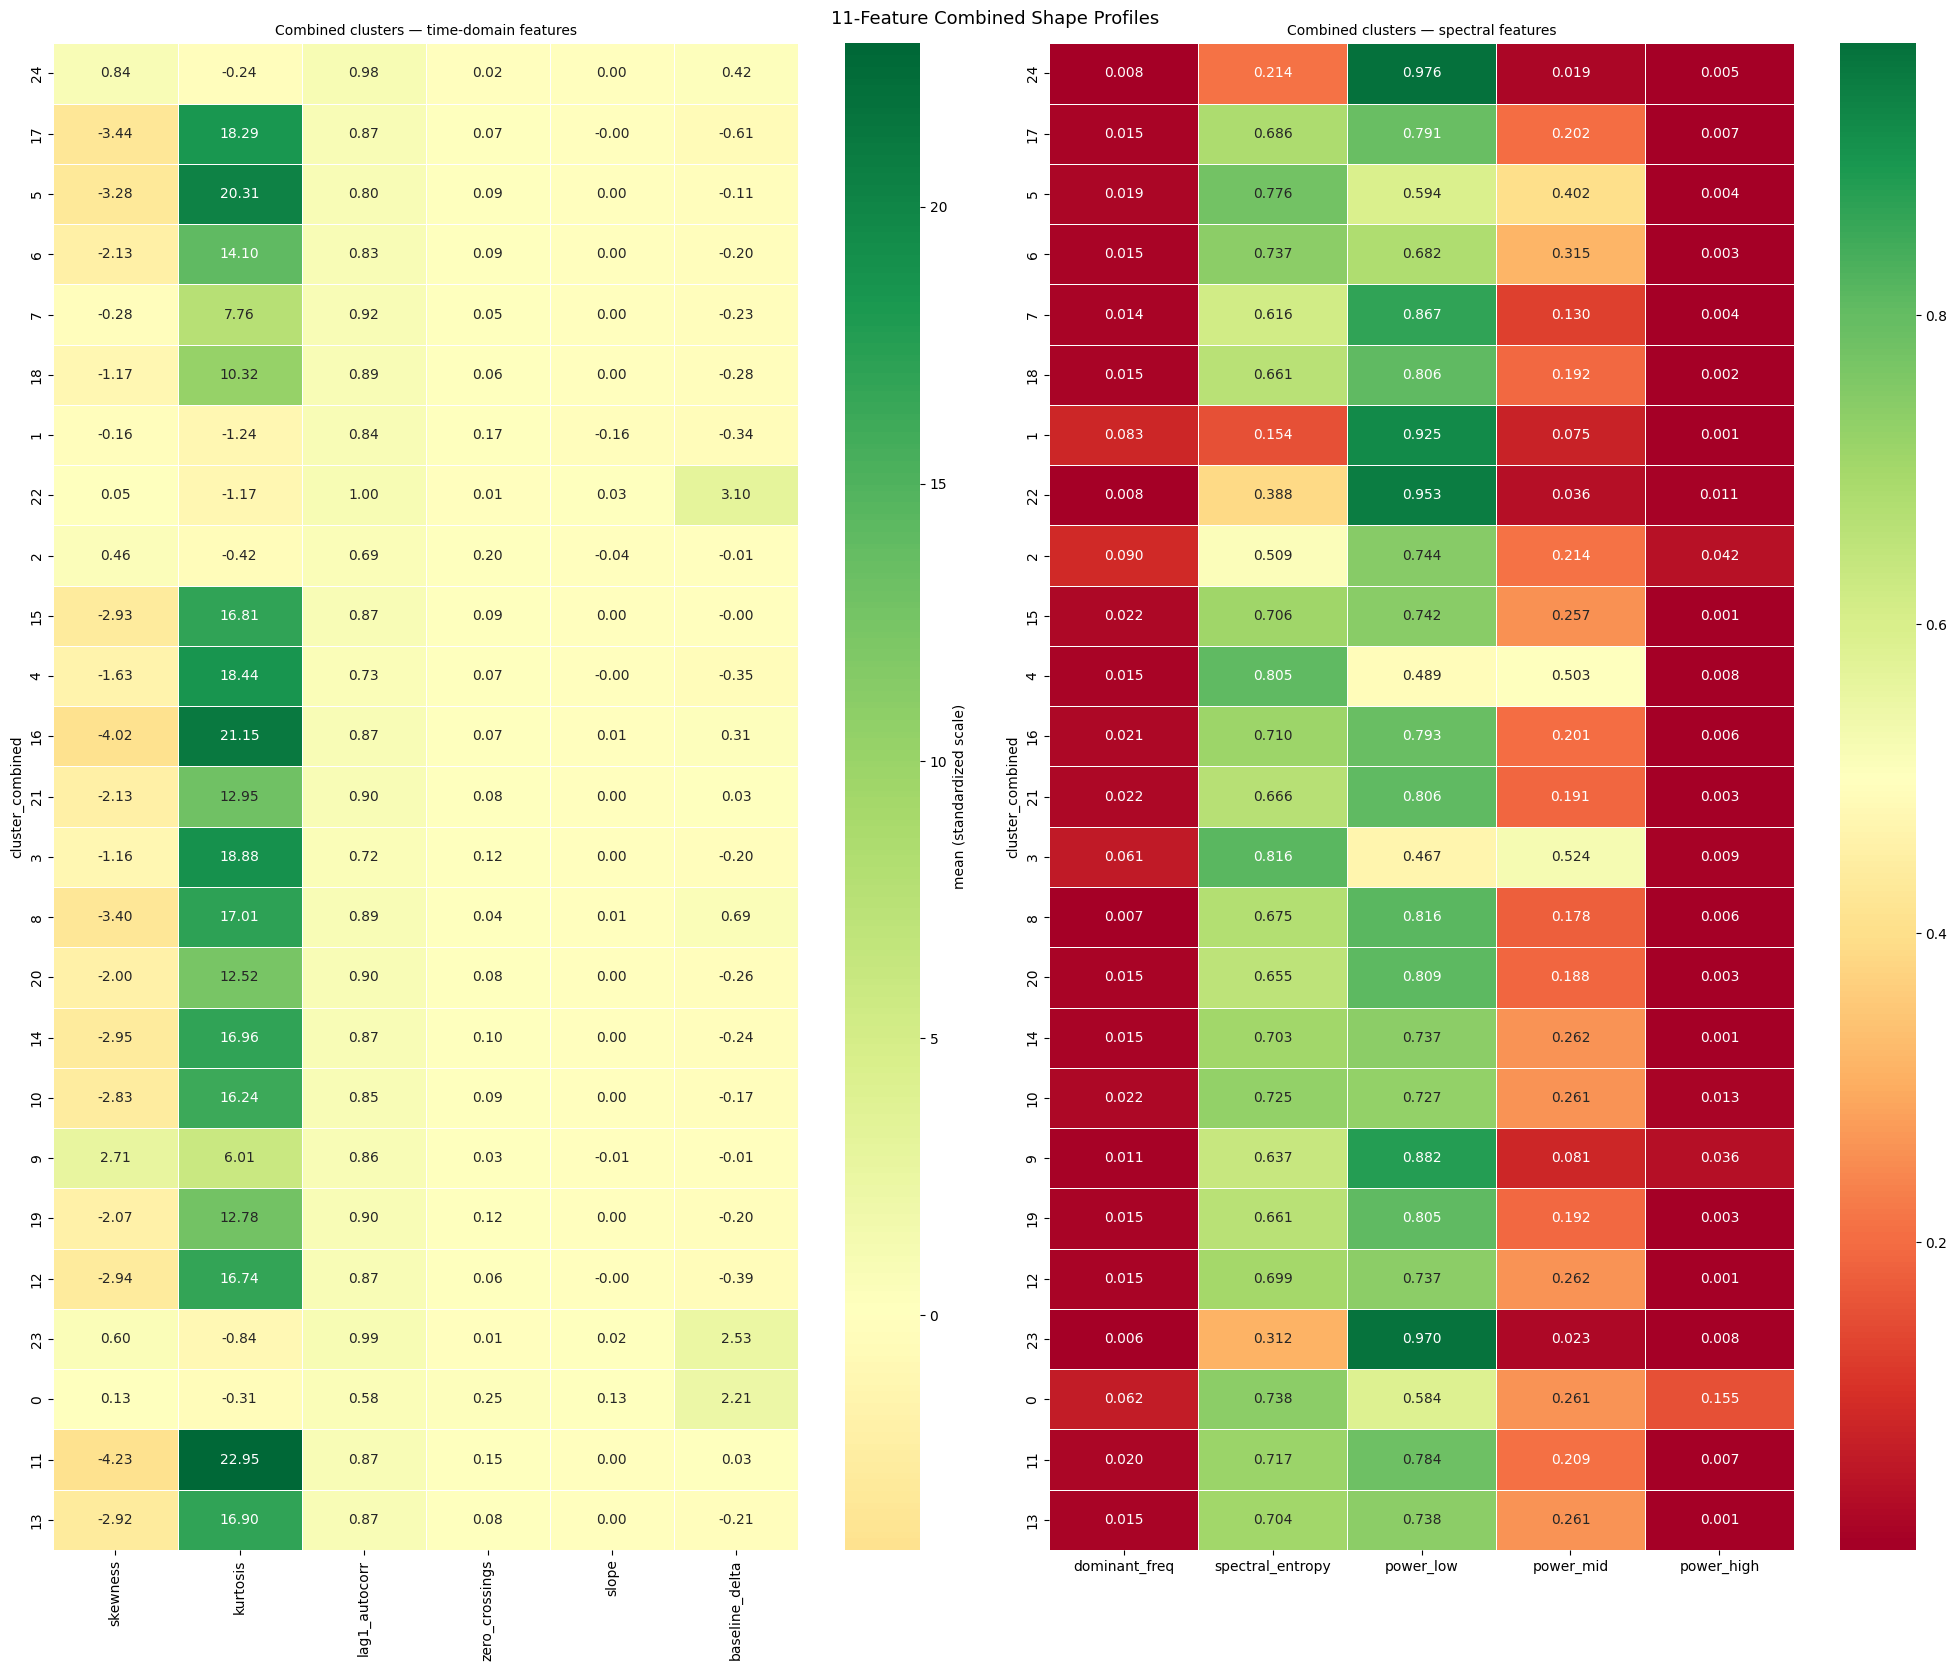

In [19]:
# Final profile heatmap for combined clusters
real_combined = df_clean[df_clean['cluster_combined'] != -1]
profiles = real_combined.groupby('cluster_combined')[COMBINED_COLS].mean().round(3)

# Only show clusters with ≥8 points
sizes = real_combined['cluster_combined'].value_counts()
profiles = profiles.loc[sizes[sizes >= 8].index]

fig, axes = plt.subplots(1, 2, figsize=(20, max(5, len(profiles)*0.6+2)))

# Time-domain half
sns.heatmap(profiles[TIMEDOM_COLS], annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=axes[0], linewidths=0.4, cbar_kws={'label': 'mean (standardized scale)'})
axes[0].set_title('Combined clusters — time-domain features', fontsize=10)

# Spectral half
sns.heatmap(profiles[SPECTRAL_COLS], annot=True, fmt='.3f', cmap='RdYlGn', center=0.5,
            ax=axes[1], linewidths=0.4)
axes[1].set_title('Combined clusters — spectral features', fontsize=10)

plt.suptitle('11-Feature Combined Shape Profiles', fontsize=13)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'combined_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Findings to record

Fill in after running:

- **ARI combined vs time-domain vs spectral**: ___
- **Did the three-way problem resolve?** (COVID / sunspot / keeling_seasonal all separate): YES / NO
- **Streamflow dominant_freq after fix**: ___ (expect ~0.083)
- **Number of clusters**: ___ (expect fewer than spectral 37, perhaps close to time-domain 22)
- **Most surprising grouping**: ___
- **Overall verdict**: combining both frames improves / does not improve the taxonomy